### Agenda:
      Remove duplicate engineered columns
      Create new predictive features
      Encode categorical variables (when appropriate)
      Handle skewed features if needed
      Create the final dataset for modeling

### In this stage we will be engineering the featurs like :
      Customer transaction frequency
      Average transaction amount per customer
      Time since the previous transaction
      Merchant risk score
      Customer historical fraud rate (carefully computed to avoid data leakage)
      Sender/receiver bank relationship features


In [71]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/raw/upi_transactions_2024.csv")

In [72]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [73]:
df.rename(columns={
    "hour_of_day" : "transaction_hour"
}, inplace=True)
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   transaction id      250000 non-null  str           
 1   timestamp           250000 non-null  datetime64[us]
 2   transaction type    250000 non-null  str           
 3   merchant_category   250000 non-null  str           
 4   amount (INR)        250000 non-null  int64         
 5   transaction_status  250000 non-null  str           
 6   sender_age_group    250000 non-null  str           
 7   receiver_age_group  250000 non-null  str           
 8   sender_state        250000 non-null  str           
 9   sender_bank         250000 non-null  str           
 10  receiver_bank       250000 non-null  str           
 11  device_type         250000 non-null  str           
 12  network_type        250000 non-null  str           
 13  fraud_flag          250000 non-null  int

In [75]:
df["night_transaction"] = ((df["transaction_hour"]>23)&(df["transaction_hour"]<=5)).astype(int)


In [76]:
df["night_transaction"].head()

0    0
1    0
2    0
3    0
4    0
Name: night_transaction, dtype: int64

In [77]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,0
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,0


In [78]:
df.rename(columns={
    "hour_of_day" : "transaction_hour"
}, inplace=True)

In [79]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,0
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,0


In [80]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,0
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,0


In [81]:
df.columns.to_list()

['transaction id',
 'timestamp',
 'transaction type',
 'merchant_category',
 'amount (INR)',
 'transaction_status',
 'sender_age_group',
 'receiver_age_group',
 'sender_state',
 'sender_bank',
 'receiver_bank',
 'device_type',
 'network_type',
 'fraud_flag',
 'transaction_hour',
 'day_of_week',
 'is_weekend',
 'night_transaction']

Creating Features Like 

   -same_bank	

   -same_age_group	

   -high_value_transaction	

   -business_hours		

   -peak_hour		

   -amount_bucket		

   -sender_bank_risk		

   -merchant_risk	

   -age_group_pair		
   
   -transaction_type_risk	

In [82]:
df["same_bank"] = (
    df["sender_bank"] == df["receiver_bank"]
).astype(int)

In [83]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction,same_bank
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,0,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,0,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,0,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,0,0
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,0,0


In [84]:
df[
    ["sender_bank", "receiver_bank","same_bank"]
].head(10)

,sender_bank,receiver_bank,same_bank
0,Axis,SBI,0
1,ICICI,Axis,0
2,Yes Bank,PNB,0
3,ICICI,PNB,0
4,Axis,Yes Bank,0
5,IndusInd,Yes Bank,0
6,HDFC,IndusInd,0
7,Yes Bank,SBI,0
8,Kotak,HDFC,0
9,SBI,HDFC,0


In [85]:
df["same_age_group"] = (
    df["sender_age_group"] == df["receiver_age_group"]
).astype(int)

In [86]:
df[
    ["sender_age_group","receiver_age_group", "same_age_group"]
].head(10)

,sender_age_group,receiver_age_group,same_age_group
0,26-35,18-25,0
1,26-35,26-35,1
2,26-35,36-45,0
3,26-35,26-35,1
4,26-35,18-25,0
5,36-45,18-25,0
6,36-45,18-25,0
7,46-55,36-45,0
8,46-55,36-45,0
9,46-55,18-25,0


Creating the high value amount threshold

In [87]:
high_value_threshold = df["amount (INR)"].quantile(0.95)
high_value_threshold

np.float64(4687.049999999988)

In [88]:
df["high_value_transaction"] = (
    df["amount (INR)"]> high_value_threshold
).astype(int)

In [89]:
df[
    ["amount (INR)", "high_value_transaction"]
].sort_values(
    by = "amount (INR)",
    ascending=False
).head(20)

,amount (INR),high_value_transaction
144868,42099,1
233820,41210,1
195366,37263,1
72465,34304,1
25258,33061,1
142496,32741,1
214955,30584,1
121682,30351,1
162783,30112,1
223738,29601,1


In [90]:
# df["business_hours"] = (
#     (df["transaction_hour"]>=9)&(df["transaction_hour"]<=21)
# ).astype(int)

In [91]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,device_type,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction,same_bank,same_age_group,high_value_transaction
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,Android,4G,0,15,Tuesday,0,0,0,0,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,iOS,4G,0,6,Thursday,0,0,0,1,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,Android,4G,0,13,Tuesday,0,0,0,0,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,Android,5G,0,10,Sunday,1,0,0,1,0
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,iOS,WiFi,0,19,Tuesday,0,0,0,0,0


In [92]:
df["peak_hour"] = (
    (
        (df["transaction_hour"]>=10)&(df["transaction_hour"]<=12) | 
        (df["transaction_hour"]>=17)&(df["transaction_hour"]<=20)
    )
).astype(int)

<Axes: xlabel='transaction_hour'>

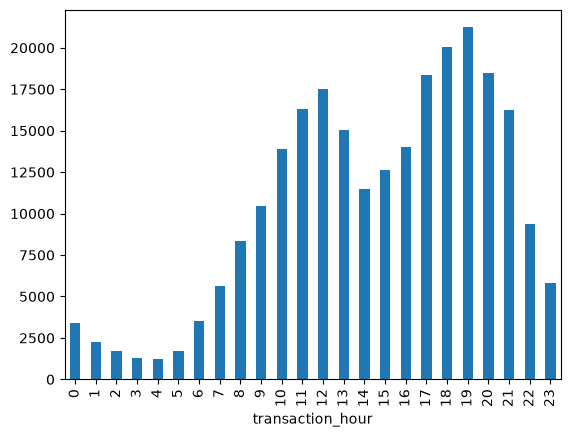

In [93]:
df["transaction_hour"].value_counts().sort_index().plot(kind="bar")

In [94]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction,same_bank,same_age_group,high_value_transaction,peak_hour
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,4G,0,15,Tuesday,0,0,0,0,0,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,4G,0,6,Thursday,0,0,0,1,0,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,4G,0,13,Tuesday,0,0,0,0,0,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,5G,0,10,Sunday,1,0,0,1,0,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,WiFi,0,19,Tuesday,0,0,0,0,0,1


In [95]:
df.to_csv("../data/processed/upi_fraud_feature_engineered.csv", index=False)

In [96]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction,same_bank,same_age_group,high_value_transaction,peak_hour
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,4G,0,15,Tuesday,0,0,0,0,0,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,4G,0,6,Thursday,0,0,0,1,0,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,4G,0,13,Tuesday,0,0,0,0,0,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,5G,0,10,Sunday,1,0,0,1,0,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,WiFi,0,19,Tuesday,0,0,0,0,0,1


In [97]:
import numpy as np
df["amount_log"] = np.log1p(df["amount (INR)"])

In [98]:
df["hour_sin"] = np.sin(
    2 * np.pi * df["transaction_hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["transaction_hour"] / 24
)

In [99]:
day_mapping = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

df["day_number"] = df["day_of_week"].map(day_mapping)

In [100]:
df["day_sin"] = np.sin(
    2 * np.pi * df["day_number"] / 7
)

df["day_cos"] = np.cos(
    2 * np.pi * df["day_number"] / 7
)

In [101]:
df.drop(columns=["day_number"], inplace=True)

In [102]:
df[
    [
        "amount (INR)",
        "amount_log",
        "transaction_hour",
        "hour_sin",
        "hour_cos",
        "day_of_week",
        "day_sin",
        "day_cos"
    ]
].head(10)

,amount (INR),amount_log,transaction_hour,hour_sin,hour_cos,day_of_week,day_sin,day_cos
0,868,6.767343,15,-0.707107,-7.071068e-01,Tuesday,0.781831,0.623490
1,1011,6.919684,6,1.000000,6.123234e-17,Thursday,0.433884,-0.900969
2,477,6.169611,13,-0.258819,-9.659258e-01,Tuesday,0.781831,0.623490
3,2784,7.932003,10,0.500000,-8.660254e-01,Sunday,-0.781831,0.623490
4,990,6.898715,19,-0.965926,2.588190e-01,Tuesday,0.781831,0.623490
5,91,4.521789,22,-0.500000,8.660254e-01,Monday,0.000000,1.000000
6,314,5.752573,10,0.500000,-8.660254e-01,Thursday,0.433884,-0.900969
7,264,5.579730,18,-1.000000,-1.836970e-16,Sunday,-0.781831,0.623490
8,887,6.788972,9,0.707107,-7.071068e-01,Thursday,0.433884,-0.900969
9,3260,8.089789,15,-0.707107,-7.071068e-01,Monday,0.000000,1.000000


In [103]:
df[
    ["amount_log", "hour_sin", "hour_cos", "day_sin", "day_cos"]
].isnull().sum()

amount_log    0
hour_sin      0
hour_cos      0
day_sin       0
day_cos       0
dtype: int64

In [104]:
df.to_csv(
    "../data/processed/upi_fraud_feature_engineered_v2.csv",
    index=False
)